In [1]:
import tqdm as notebook_tqdm
from datasets import get_dataset_config_names
xtreme_subsets = get_dataset_config_names("google/xtreme")
print(f"XTREME has {len(xtreme_subsets)} configurations")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md:   0%|          | 0.00/131k [00:00<?, ?B/s]

XTREME has 183 configurations


In [2]:
panx_subsets = [s for s in xtreme_subsets if s.startswith("PAN")]
panx_subsets[:5]


['PAN-X.af', 'PAN-X.ar', 'PAN-X.bg', 'PAN-X.bn', 'PAN-X.de']

In [3]:
from collections import defaultdict
from datasets import DatasetDict, load_dataset

langs = ["de","fr","it","en"]
fracs = [0.629, 0.229, 0.084, 0.059]

panx_ch = defaultdict(DatasetDict)
for lang, frac in zip(langs, fracs):
    ds = load_dataset("google/xtreme", name = f"PAN-X.{lang}")
    for split in ds:
        panx_ch[lang][split] = (
            ds[split]
            .shuffle(seed = 0)
            .select(range(int(frac * ds[split].num_rows)))
        )

PAN-X.de/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.18MB            

PAN-X.de/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

PAN-X.de/validation-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B /  590kB            

PAN-X.de/validation-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

PAN-X.de/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  588kB            

...

PAN-X.en/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  472kB            

PAN-X.en/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [4]:
panx_ch

defaultdict(datasets.dataset_dict.DatasetDict,
            {'de': DatasetDict({
                 train: Dataset({
                     features: ['tokens', 'ner_tags', 'langs'],
                     num_rows: 12580
                 })
                 validation: Dataset({
                     features: ['tokens', 'ner_tags', 'langs'],
                     num_rows: 6290
                 })
                 test: Dataset({
                     features: ['tokens', 'ner_tags', 'langs'],
                     num_rows: 6290
                 })
             }),
             'fr': DatasetDict({
                 train: Dataset({
                     features: ['tokens', 'ner_tags', 'langs'],
                     num_rows: 4580
                 })
                 validation: Dataset({
                     features: ['tokens', 'ner_tags', 'langs'],
                     num_rows: 2290
                 })
                 test: Dataset({
                     features: ['tokens', 'ner_tags', 'la

In [5]:
# taking the first training example from German dataset
element = panx_ch['de']['train'][0]
print(element)

{'tokens': ['2.000', 'Einwohnern', 'an', 'der', 'Danziger', 'Bucht', 'in', 'der', 'polnischen', 'Woiwodschaft', 'Pommern', '.'], 'ner_tags': [0, 0, 0, 0, 5, 6, 0, 0, 5, 5, 6, 0], 'langs': ['de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de']}


In [6]:
# understanding features of dataset
panx_ch['de']['train'].features

{'tokens': List(Value('string')),
 'ner_tags': List(ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'])),
 'langs': List(Value('string'))}

In [7]:
# extracting label mappings from ner tags
tags = (
    panx_ch['de']['train']
    .features['ner_tags'].feature
)
tags

ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'])

In [8]:
# converting IDs to string
def create_tag_names(batch):
    return {
        "ner_tags_str":
        [
            tags.int2str(idx)
            for idx in batch["ner_tags"]
        ]
    }

In [9]:
# apply to whole dataset
panx_de = panx_ch["de"].map(create_tag_names)

Map:   0%|          | 0/12580 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

In [10]:
print(panx_de['train'][0])

{'tokens': ['2.000', 'Einwohnern', 'an', 'der', 'Danziger', 'Bucht', 'in', 'der', 'polnischen', 'Woiwodschaft', 'Pommern', '.'], 'ner_tags': [0, 0, 0, 0, 5, 6, 0, 0, 5, 5, 6, 0], 'langs': ['de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de', 'de'], 'ner_tags_str': ['O', 'O', 'O', 'O', 'B-LOC', 'I-LOC', 'O', 'O', 'B-LOC', 'B-LOC', 'I-LOC', 'O']}


In [11]:
panx_de.items()

dict_items([('train', Dataset({
    features: ['tokens', 'ner_tags', 'langs', 'ner_tags_str'],
    num_rows: 12580
})), ('validation', Dataset({
    features: ['tokens', 'ner_tags', 'langs', 'ner_tags_str'],
    num_rows: 6290
})), ('test', Dataset({
    features: ['tokens', 'ner_tags', 'langs', 'ner_tags_str'],
    num_rows: 6290
}))])

In [12]:
# Counting the entities(person, location, organization) frequency
from collections import Counter
import pandas as pd

split2freqs = defaultdict(Counter)
for split, dataset in panx_de.items():
    for row in dataset['ner_tags_str']:
        for tag in row:
            if tag.startswith("B"):
                tag_type = tag.split('-')[1]
                split2freqs[split][tag_type] += 1

pd.DataFrame.from_dict(split2freqs, orient = "index")

,LOC,ORG,PER
train,6186,5366,5810
validation,3172,2683,2893
test,3180,2573,3071


In [13]:
# A Closer Look at Tokenization


from transformers import AutoTokenizer

bert_model_name = "bert-base-cased"
xlmr_model_name = "xlm-roberta-base"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
xlmr_tokenizer = AutoTokenizer.from_pretrained(xlmr_model_name)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [14]:
text = "Jack Sparrow loves New York!"
bert_tokens = bert_tokenizer(text).tokens()
xlmr_tokens = xlmr_tokenizer(text).tokens()
print("BERT Tokens:",bert_tokens)
print("XLMR Tokens:",xlmr_tokens)

BERT Tokens: ['[CLS]', 'Jack', 'Spa', '##rrow', 'loves', 'New', 'York', '!', '[SEP]']
XLMR Tokens: ['<s>', '▁Jack', '▁Spar', 'row', '▁love', 's', '▁New', '▁York', '!', '</s>']


## **Creating a Custom Model for Token Classification**

In [15]:
import torch.nn as nn
from transformers import XLMRobertaConfig # for model configuration
from transformers.modeling_outputs import TokenClassifierOutput # has outputs like loss,logits,hidden_states,attentions
from transformers.models.roberta.modeling_roberta import RobertaModel # the only Encoder
from transformers.models.roberta.modeling_roberta import RobertaPreTrainedModel # inherited parent class with predefined functions and can be reused via inheritance

class XLMRobertaForTokenClassification(RobertaPreTrainedModel):
    config_class = XLMRobertaConfig

    def __init__(self, config):
        super().__init__(config)

        self.num_labels = config.num_labels

        # loading the body(model) this loads the only-Encoder Model's hidden states
        self.roberta = RobertaModel(
            config,
            add_pooling_layer = False # we need every token but pooling_layer creates each sentence representation so False
        )

        # set up token classification head
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

        # load and initialize weights
        self.init_weights()

    def forward(self, input_ids = None, attention_mask = None, token_type_ids = None, labels = None, **kwargs):
        # use model body to get encoder representations
        outputs = self.roberta(input_ids, attention_mask = attention_mask, token_type_ids = token_type_ids, **kwargs)
        # apply classifier to encoder representations
        sequence_output = self.dropout(outputs[0])
        logits = self.classifier(sequence_output)
        # calculate losses
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))
        # Return model output object
        return TokenClassifierOutput(loss=loss, logits=logits,
                                     hidden_states=outputs.hidden_states,
                                     attentions=outputs.attentions)

## **Loading a custom Model**

In [16]:
index2tag = {idx: tag for idx, tag in enumerate(tags.names)}
tag2index = {tag: idx for idx, tag in enumerate(tags.names)}

# modify the config for xlmr_roberta so it understands the config for NER tags
from transformers import AutoConfig
xlmr_config = AutoConfig.from_pretrained(
  xlmr_model_name,
  num_labels = tags.num_classes,
  id2label = index2tag,
  label2id = tag2index
)

In [17]:
import torch
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

# loading the pretrained model
from transformers import XLMRobertaForTokenClassification

xlmr_model = XLMRobertaForTokenClassification.from_pretrained(
    xlmr_model_name,
    config=xlmr_config
).to(device)


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
input_ids = xlmr_tokenizer.encode(text, return_tensors="pt")
pd.DataFrame([xlmr_tokens, input_ids[0].numpy()], index=["Tokens", "Input IDs"])

,0,1,2,3,4,5,6,7,8,9
Tokens,<s>,▁Jack,▁Spar,row,▁love,s,▁New,▁York,!,</s>
Input IDs,0,21763,37456,15555,5161,7,2356,5753,38,2


In [19]:
outputs = xlmr_model(input_ids.to(device)).logits
predictions = torch.argmax(outputs, dim=-1)
print(f"Number of tokens in sequence: {len(xlmr_tokens)}")
print(f"Shape of outputs: {outputs.shape}")

Number of tokens in sequence: 10
Shape of outputs: torch.Size([1, 10, 7])


In [20]:
preds = [tags.names[p] for p in predictions[0].cpu().numpy()]
pd.DataFrame([xlmr_tokens, preds], index=["Tokens", "Tags"])

,0,1,2,3,4,5,6,7,8,9
Tokens,<s>,▁Jack,▁Spar,row,▁love,s,▁New,▁York,!,</s>
Tags,B-LOC,B-PER,B-PER,B-PER,B-PER,B-PER,B-PER,B-PER,B-PER,B-LOC


In [21]:
predictions = torch.argmax(
    outputs,
    dim=-1
)
preds = [
    tags.names[p]
    for p in predictions[0]
]

In [22]:
def tag_text(text, tags, model, tokenizer):
 # Get tokens with special characters
 tokens = tokenizer(text).tokens()
 # Encode the sequence into IDs
 input_ids = xlmr_tokenizer(text, return_tensors="pt").input_ids.to(device)
 # Get predictions as distribution over 7 possible classes
 outputs = model(input_ids)[0]
 # Take argmax to get most likely class per token
 predictions = torch.argmax(outputs, dim=2)
 # Convert to DataFrame
 preds = [tags.names[p] for p in predictions[0].cpu().numpy()]
 return pd.DataFrame([tokens, preds], index=["Tokens", "Tags"])

## **Tokenizing the text for NER**

In [23]:
def tokenize_and_align_labels(examples):
  tokenized_inputs = xlmr_tokenizer(examples["tokens"], truncation=True,
  is_split_into_words=True)
  labels = []
  for idx, label in enumerate(examples["ner_tags"]):
    word_ids = tokenized_inputs.word_ids(batch_index=idx)
    previous_word_idx = None
    label_ids = []
    for word_idx in word_ids:
      if word_idx is None or word_idx == previous_word_idx:
        label_ids.append(-100)
      else:
        label_ids.append(label[word_idx])
      previous_word_idx = word_idx
    labels.append(label_ids)
  tokenized_inputs["labels"] = labels
  return tokenized_inputs

In [24]:
def encode_panx_dataset(corpus):
 return corpus.map(tokenize_and_align_labels, batched=True,
 remove_columns=['langs', 'ner_tags', 'tokens'])

In [25]:
panx_de_encoded = encode_panx_dataset(panx_ch["de"])

Map:   0%|          | 0/12580 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

In [26]:
panx_de_encoded

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 12580
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 6290
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 6290
    })
})

In [27]:
%pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=24484ea0a392a298980cc57d2fb119188a485bd50b0215d4f65d4cc45ce4148b
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


## **Peformance Measures**

In [30]:
from seqeval.metrics import classification_report
y_true = [["O", "O", "O", "B-MISC", "I-MISC", "I-MISC", "O"],
 ["B-PER", "I-PER", "O"]]
y_pred = [["O", "O", "B-MISC", "I-MISC", "I-MISC", "I-MISC", "O"],
 ["B-PER", "I-PER", "O"]]
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

        MISC       0.00      0.00      0.00         1
         PER       1.00      1.00      1.00         1

   micro avg       0.50      0.50      0.50         2
   macro avg       0.50      0.50      0.50         2
weighted avg       0.50      0.50      0.50         2



In [31]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

        MISC       0.00      0.00      0.00         1
         PER       1.00      1.00      1.00         1

   micro avg       0.50      0.50      0.50         2
   macro avg       0.50      0.50      0.50         2
weighted avg       0.50      0.50      0.50         2



In [46]:
# During training The model outputs (batch_size, sequence_length, num_labels) Example (16,128,7)
# But seqeval expects
# [
#   ["O","B-PER","I-PER"],
#   ["O","B-LOC"]
#]
# So we need a conversion function.
import numpy as np
def align_predictions(predictions, label_ids):
  preds = np.argmax(predictions, axis=2)
  batch_size, seq_len = preds.shape
  labels_list, preds_list = [], []

  for batch_idx in range(batch_size):
    example_labels, example_preds = [], []
    for seq_idx in range(seq_len):
      # Ignore label IDs = -100
      if label_ids[batch_idx, seq_idx] != -100:
        example_labels.append(index2tag[label_ids[batch_idx][seq_idx]])
        example_preds.append(index2tag[preds[batch_idx][seq_idx]])

    labels_list.append(example_labels)
    preds_list.append(example_preds)
  return preds_list, labels_list

## **Fine Tuning XLM-ROBERTa**

In [47]:
from transformers import TrainingArguments # a container that stores all settings needed for training

num_epochs = 3
batch_size = 24
logging_steps = len(panx_de_encoded["train"]) // batch_size
model_name = f"{xlmr_model_name}-finetuned-panx-de"
training_args = TrainingArguments(
    output_dir=model_name,
    log_level="error",
    num_train_epochs=num_epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    eval_strategy="epoch",         # NEW
    save_steps=1_000_000,
    weight_decay=0.01,
    disable_tqdm=False,
    logging_steps=logging_steps,
    push_to_hub=True
)


In [37]:
from huggingface_hub import notebook_login

notebook_login()

In [48]:
from seqeval.metrics import f1_score
def compute_metrics(eval_pred):
 y_pred, y_true = align_predictions(eval_pred.predictions,
 eval_pred.label_ids)
 return {"f1": f1_score(y_true, y_pred)}

In [49]:
from transformers import DataCollatorForTokenClassification
data_collator = DataCollatorForTokenClassification(xlmr_tokenizer)

In [50]:
def model_init():
  return (XLMRobertaForTokenClassification
  .from_pretrained(xlmr_model_name, config=xlmr_config)
  .to(device))

In [51]:
from transformers import Trainer
trainer = Trainer(
    model_init=model_init,
    args=training_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    train_dataset=panx_de_encoded["train"],
    eval_dataset=panx_de_encoded["validation"],
    processing_class=xlmr_tokenizer
)

trainer.train()
trainer.push_to_hub(commit_message="Training completed!")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,F1
1,0.252973,0.150081,0.823938
2,0.125864,0.131867,0.858454


Epoch,Training Loss,Validation Loss,F1
1,0.252973,0.150081,0.823938
2,0.125864,0.131867,0.858454
3,0.077504,0.138376,0.864776


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

No files have been modified since last commit. Skipping to prevent empty commit.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

CommitInfo(commit_url='https://huggingface.co/OmCodex/xlm-roberta-base-finetuned-panx-de/commit/213c7796c27ef8574e9bf46b266950aeef64939d', commit_message='Training completed!', commit_description='', oid='213c7796c27ef8574e9bf46b266950aeef64939d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/OmCodex/xlm-roberta-base-finetuned-panx-de', endpoint='https://huggingface.co', repo_type='model', repo_id='OmCodex/xlm-roberta-base-finetuned-panx-de'), pr_revision=None, pr_num=None)

In [52]:
text_de = "Jeff Dean ist ein Informatiker bei Google in Kalifornien"
tag_text(text_de, tags, trainer.model, xlmr_tokenizer)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
Tokens,<s>,▁Jeff,▁De,an,▁ist,▁ein,▁Informati,ker,▁bei,▁Google,▁in,▁Kaliforni,en,</s>
Tags,O,B-PER,I-PER,I-PER,O,O,O,O,O,B-ORG,O,B-LOC,I-LOC,O


In [53]:
from torch.nn.functional import cross_entropy
def forward_pass_with_label(batch):
  # Convert dict of lists to list of dicts suitable for data collator
  features = [dict(zip(batch, t)) for t in zip(*batch.values())]
  # Pad inputs and labels and put all tensors on device
  batch = data_collator(features)
  input_ids = batch["input_ids"].to(device)
  attention_mask = batch["attention_mask"].to(device)
  labels = batch["labels"].to(device)
  with torch.no_grad():
    # Pass data through model
    output = trainer.model(input_ids, attention_mask)
    # logit.size: [batch_size, sequence_length, classes]
    # Predict class with largest logit value on classes axis
    predicted_label = torch.argmax(output.logits, axis=-1).cpu().numpy()
  # Calculate loss per token after flattening batch dimension with view
  loss = cross_entropy(output.logits.view(-1, 7),
  labels.view(-1), reduction="none")
  # Unflatten batch dimension and convert to numpy array
  loss = loss.view(len(input_ids), -1).cpu().numpy()
  return {"loss":loss, "predicted_label": predicted_label}

In [54]:
valid_set = panx_de_encoded["validation"]
valid_set = valid_set.map(forward_pass_with_label, batched=True, batch_size=32)
df = valid_set.to_pandas()

Map:   0%|          | 0/6290 [00:00<?, ? examples/s]

In [55]:
index2tag[-100] = "IGN"
df["input_tokens"] = df["input_ids"].apply(
 lambda x: xlmr_tokenizer.convert_ids_to_tokens(x))
df["predicted_label"] = df["predicted_label"].apply(
 lambda x: [index2tag[i] for i in x])


In [56]:
df["labels"] = df["labels"].apply(
 lambda x: [index2tag[i] for i in x])
df['loss'] = df.apply(
 lambda x: x['loss'][:len(x['input_ids'])], axis=1)
df['predicted_label'] = df.apply(
 lambda x: x['predicted_label'][:len(x['input_ids'])], axis=1)
df.head(1)

,input_ids,attention_mask,labels,loss,predicted_label,input_tokens
0,"[0, 10699, 11, 15, 16104, 1388, 2]","[1, 1, 1, 1, 1, 1, 1]","[IGN, B-ORG, IGN, I-ORG, I-ORG, I-ORG, IGN]","[0.0, 0.007421779, 0.0, 0.007507681, 0.0065461...","[I-ORG, B-ORG, I-ORG, I-ORG, I-ORG, I-ORG, I-ORG]","[<s>, ▁Ham, a, ▁(, ▁Unternehmen, ▁), </s>]"


In [57]:
df_tokens = df.apply(pd.Series.explode)
df_tokens = df_tokens.query("labels != 'IGN'")
df_tokens["loss"] = df_tokens["loss"].astype(float).round(2)
df_tokens.head(7)

,input_ids,attention_mask,labels,loss,predicted_label,input_tokens
0,10699,1,B-ORG,0.01,B-ORG,▁Ham
0,15,1,I-ORG,0.01,I-ORG,▁(
0,16104,1,I-ORG,0.01,I-ORG,▁Unternehmen
0,1388,1,I-ORG,0.01,I-ORG,▁)
1,56530,1,O,0.00,O,▁WE
1,83982,1,B-ORG,1.17,B-LOC,▁Luz
1,10,1,I-ORG,0.69,I-ORG,▁a


In [58]:
(
 df_tokens.groupby("input_tokens")[["loss"]]
 .agg(["count", "mean", "sum"])
 .droplevel(level=0, axis=1) # Get rid of multi-level columns
 .sort_values(by="sum", ascending=False)
 .reset_index()
 .round(2)
 .head(10)
 .T
)


,0,1,2,3,4,5,6,7,8,9
input_tokens,▁,▁in,▁der,▁/,▁von,▁und,▁(,▁),▁'',▁A
count,6066,989,1388,163,808,1171,246,246,2898,125
mean,0.03,0.14,0.09,0.7,0.13,0.08,0.33,0.3,0.02,0.47
sum,211.19,137.41,125.84,113.62,104.07,97.91,80.35,74.53,65.0,59.25


In [59]:
(
 df_tokens.groupby("labels")[["loss"]]
 .agg(["count", "mean", "sum"])
 .droplevel(level=0, axis=1)
 .sort_values(by="mean", ascending=False)
 .reset_index()
 .round(2)
 .T
)

,0,1,2,3,4,5,6
labels,B-ORG,I-LOC,I-ORG,B-LOC,B-PER,I-PER,O
count,2683,1462,3820,3172,2893,4139,43648
mean,0.61,0.58,0.51,0.33,0.28,0.2,0.03
sum,1632.37,853.62,1944.19,1047.45,798.41,830.53,1379.46


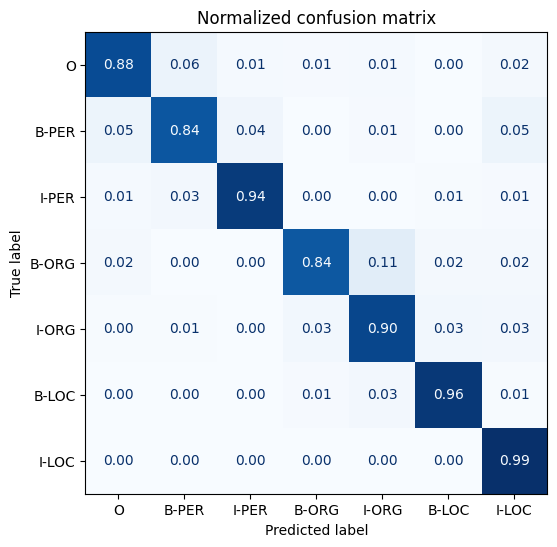

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
def plot_confusion_matrix(y_preds, y_true, labels):
 cm = confusion_matrix(y_true, y_preds, normalize="true")
 fig, ax = plt.subplots(figsize=(6, 6))
 disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
 disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
 plt.title("Normalized confusion matrix")
 plt.show()
plot_confusion_matrix(df_tokens["labels"], df_tokens["predicted_label"],
 tags.names)


In [61]:
def get_samples(df):
 for _, row in df.iterrows():
  labels, preds, tokens, losses = [], [], [], []
  for i, mask in enumerate(row["attention_mask"]):
    if i not in {0, len(row["attention_mask"])}:
      labels.append(row["labels"][i])
      preds.append(row["predicted_label"][i])
      tokens.append(row["input_tokens"][i])
      losses.append(f"{row['loss'][i]:.2f}")
  df_tmp = pd.DataFrame({"tokens": tokens, "labels": labels,
  "preds": preds, "losses": losses}).T
  yield df_tmp
df["total_loss"] = df["loss"].apply(sum)
df_tmp = df.sort_values(by="total_loss", ascending=False).head(3)
for sample in get_samples(df_tmp):
  display(sample)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
tokens,▁'',8,.,▁Juli,▁'',▁:,▁Protest,camp,▁auf,▁dem,▁Gelände,▁der,▁Republika,n,ischen,▁Gar,de,</s>
labels,B-ORG,IGN,IGN,I-ORG,I-ORG,I-ORG,I-ORG,IGN,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,IGN,IGN,I-ORG,IGN,IGN
preds,O,O,O,O,O,O,O,O,O,O,O,O,B-ORG,I-ORG,I-ORG,I-ORG,I-ORG,O
losses,9.44,0.00,0.00,5.68,9.55,9.69,6.43,0.00,8.09,9.61,8.60,6.77,5.13,0.00,0.00,0.01,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
tokens,▁',▁'',▁Τ,Κ,▁'',▁',▁',▁'',▁T,▁'',▁',ri,▁'',▁',k,▁'',▁',ala,</s>
labels,O,O,O,IGN,O,O,B-LOC,I-LOC,I-LOC,I-LOC,I-LOC,IGN,I-LOC,I-LOC,IGN,I-LOC,I-LOC,IGN,IGN
preds,O,O,B-ORG,B-ORG,O,O,O,O,O,O,O,I-ORG,O,O,O,O,O,B-ORG,O
losses,0.00,0.00,3.08,0.00,0.00,0.00,10.60,10.50,7.98,7.30,5.93,0.00,6.27,8.54,0.00,9.23,7.51,0.00,0.00


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
tokens,▁United,▁Nations,▁Multi,dimensional,▁Integra,ted,▁Stabil,ization,▁Mission,▁in,▁the,▁Central,▁African,▁Republic,</s>
labels,B-PER,I-PER,I-PER,IGN,I-PER,IGN,I-PER,IGN,I-PER,I-PER,I-PER,I-PER,I-PER,I-PER,IGN
preds,B-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG
losses,7.04,6.10,6.41,0.00,6.17,0.00,5.88,0.00,5.53,5.59,5.71,5.43,5.41,5.66,0.00


In [62]:
df_tmp = df.loc[df["input_tokens"].apply(lambda x: u"\u2581(" in x)].head(2)
for sample in get_samples(df_tmp):
 display(sample)

,0,1,2,3,4,5
tokens,▁Ham,a,▁(,▁Unternehmen,▁),</s>
labels,B-ORG,IGN,I-ORG,I-ORG,I-ORG,IGN
preds,B-ORG,I-ORG,I-ORG,I-ORG,I-ORG,I-ORG
losses,0.01,0.00,0.01,0.01,0.01,0.00


,0,1,2,3,4,5,6,7
tokens,▁Kesk,kül,a,▁(,▁Mart,na,▁),</s>
labels,B-LOC,IGN,IGN,I-LOC,I-LOC,IGN,I-LOC,IGN
preds,B-LOC,I-LOC,I-LOC,I-LOC,I-LOC,I-LOC,I-LOC,I-LOC
losses,0.02,0.00,0.00,0.02,0.02,0.00,0.02,0.00
